In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import numpy as np 
import matplotlib.pyplot as plt
import matplotlib as mpl 
import os
import sys

from pe_injections import create_injection

### mismatch quantity

The detection requirement is
$$
\langle\delta h|\delta h\rangle > 2\rho^2\epsilon_\mathrm{min}
$$
with $\delta h = h_\mathrm{II} - h_\mathrm{I}$ and $\rho$ the SNR.

Note the orbital phase shift in the degeneracy
$$
\hat h_\mathrm{II}\approx i\hat h_\mathrm{I}(\phi + \pi/4)
$$

### pseudocode

In [2]:
# define event parameters

# create injection with Gaussian noise => hI

# multiply by i => hII

# compute residual dh = hII - hI

# compute match inner product

# determine epsilon_min as a function of SNR ?

### create event

In [3]:
# define event parameters
params_to_inject = {
    'd_luminosity' : 500.,   # Mpc
    'iota' : np.pi / 3,
    'm1' : 40., # Msun
    'm2' : 20., # Msun
    's1z' : 0.,
    's2z' : 0.,
    'psi' : 0.5
}

seed = 12

# unlensed event
eventname = f'GW{seed}'
event_data = create_injection(eventname, seed, params_to_inject)

# multiply by i to get lensed
event_data_lensed = event_data.reinstantiate(strain=1j*event_data.strain)

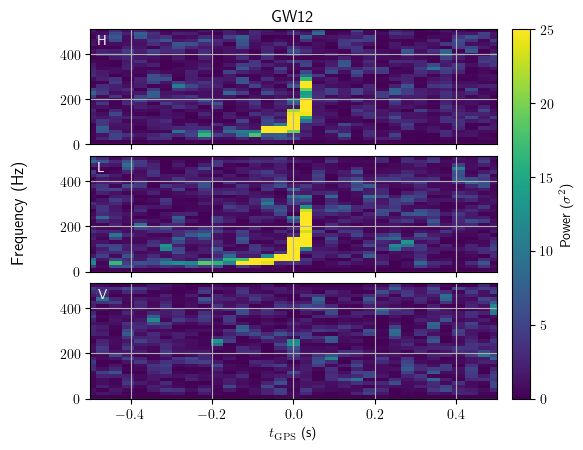

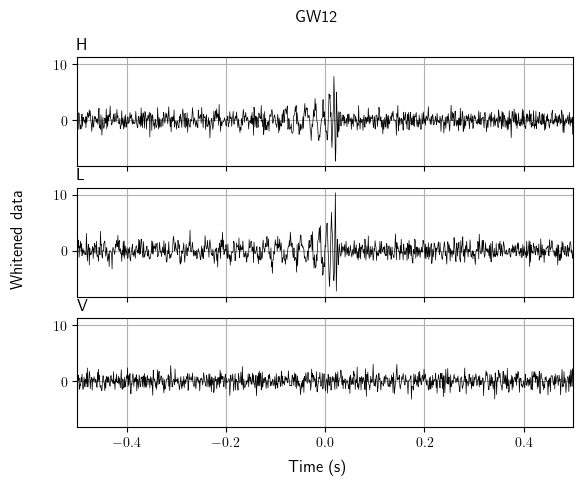

In [4]:
# check out the event data
xlim = (-0.5,0.5)
event_data.specgram(xlim=xlim)

# and plot the whitened time-domain data
whitened_td = event_data.get_whitened_td()
fig, axs = plt.subplots(len(event_data.detector_names), sharex=True, sharey=True)
for det_name, ax, wht_strain in zip(event_data.detector_names, axs, whitened_td):
    ax.plot(event_data.times - event_data.tcoarse, wht_strain, c='k', lw=0.5)
    ax.grid()
    ax.set_title(det_name, loc='left')

ax.set_xlim(xlim)
fig.supxlabel('Time (s)')
fig.supylabel('Whitened data')
fig.suptitle(event_data.eventname);

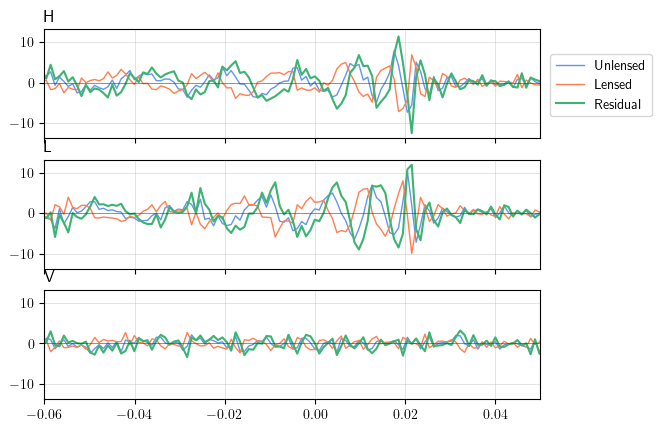

In [23]:
# compare the unlensed and lensed waveforms
whitened_td = event_data.get_whitened_td()
whitened_td_lensed = event_data_lensed.get_whitened_td()

# compute the time-domain residual
# first make sure the times are the same
assert np.allclose(event_data.times, event_data_lensed.times)
assert event_data.tcoarse == event_data_lensed.tcoarse

res_td = whitened_td - whitened_td_lensed

fig, axs = plt.subplots(len(event_data.detector_names), sharex=True, sharey=True)
for i, (det_name, ax) in enumerate(zip(event_data.detector_names, axs)):
    ax.plot(event_data.times - event_data.tcoarse, whitened_td[i], c='cornflowerblue', lw=1, label='Unlensed')
    ax.plot(event_data_lensed.times - event_data_lensed.tcoarse, whitened_td_lensed[i], c='coral', lw=1, label='Lensed')
    ax.plot(event_data_lensed.times - event_data_lensed.tcoarse, res_td[i], c='mediumseagreen', lw=1.5, label='Residual')
    ax.set_xlim(-0.06, 0.05)
    ax.grid(lw=0.5, alpha=0.5)
    ax.axhline(0., c='k', lw=0.5, alpha=0.5)
    ax.set_title(det_name, loc='left')
    if i == 0:
        ax.legend(loc=(1.02, 0.2))

In [ ]:
# what's the SNR?
